In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the clustered dataset from Day 4
df = pd.read_csv(r"C:\Users\vidisha bhat\Downloads\archive\spotify_clustered.csv")

print("Dataset loaded:", df.shape)
df.head()

Dataset loaded: (89741, 23)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,cluster,pca1,pca2
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,0,0.676,0.4610,1,...,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,3,0.687034,1.048990
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,0,0.420,0.1660,1,...,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,0,-3.189236,1.035552
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,0,0.438,0.3590,0,...,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,0,-1.315996,-0.216949
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,0,0.266,0.0596,0,...,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,0,-3.189120,-0.499169
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,0,0.618,0.4430,2,...,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,0,-0.886528,0.271098


In [2]:
# Select features for predicting popularity
features = ['danceability', 'energy', 'loudness', 'speechiness', 
            'acousticness', 'instrumentalness', 'liveness', 
            'valence', 'tempo', 'duration_ms', 'explicit']

X = df[features]
y = df['popularity']

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (71792, 11)
Testing set size: (17949, 11)


In [3]:
# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluate the model
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results:")
print(f"RMSE: {rmse_lr:.2f}")
print(f"MAE: {mae_lr:.2f}")
print(f"R² Score: {r2_lr:.3f}")

Linear Regression Results:
RMSE: 20.16
MAE: 16.61
R² Score: 0.030


In [4]:
# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results:")
print(f"RMSE: {rmse_rf:.2f}")
print(f"MAE: {mae_rf:.2f}")
print(f"R² Score: {r2_rf:.3f}")

Random Forest Results:
RMSE: 18.43
MAE: 14.66
R² Score: 0.189


Feature Importance:
             feature  importance
4       acousticness    0.130976
9        duration_ms    0.115047
0       danceability    0.106535
5   instrumentalness    0.101444
7            valence    0.099562
3        speechiness    0.098030
2           loudness    0.090622
8              tempo    0.087328
1             energy    0.084843
6           liveness    0.076191
10          explicit    0.009421


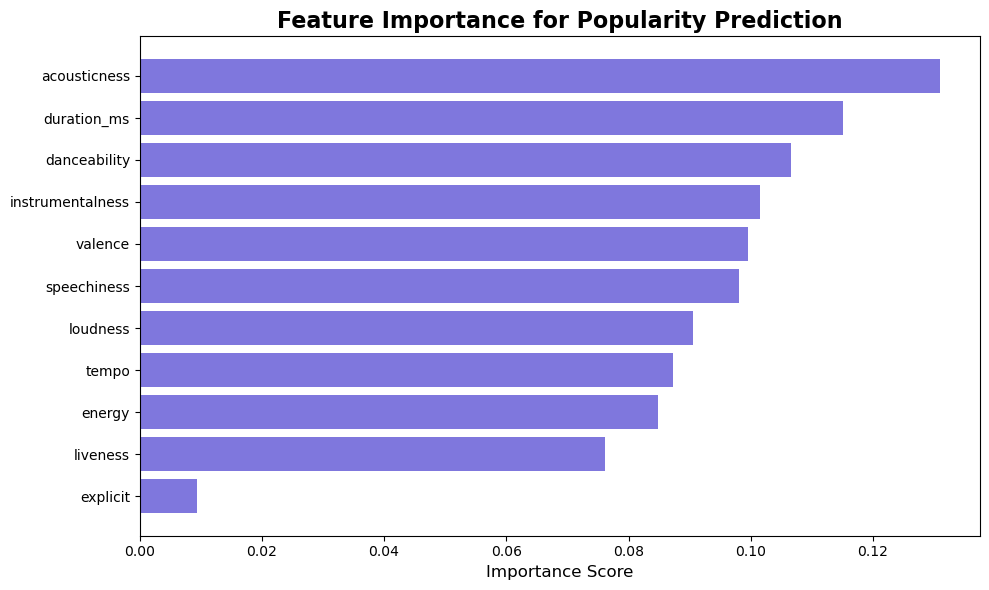

Feature importance chart saved!


In [5]:
# Feature importance from Random Forest
importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance:")
print(importance)

# Visualize it
plt.figure(figsize=(10, 6))
plt.barh(importance['feature'], importance['importance'], color='#7F77DD')
plt.title('Feature Importance for Popularity Prediction', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('chart8_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance chart saved!")

In [6]:
# Save the trained model results summary
print("Day 5 Summary:")
print(f"Linear Regression R²: {r2_lr:.3f}")
print(f"Random Forest R²: {r2_rf:.3f}")
print(f"Best model: Random Forest (improved R² by {(r2_rf - r2_lr):.3f})")
print(f"Most important feature: {importance.iloc[0]['feature']}")
print("\nDay 5 (Popularity Prediction) complete!")

Day 5 Summary:
Linear Regression R²: 0.030
Random Forest R²: 0.189
Best model: Random Forest (improved R² by 0.159)
Most important feature: acousticness

Day 5 (Popularity Prediction) complete!
